# Logistic Regression Classification

## Breast Cancer Wisconsin Dataset

### Objective
Build a Logistic Regression model for binary classification and evaluate its predictions on unseen data.

### Tools
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Breast Cancer Wisconsin dataset
data = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Create target column
df["target"] = data.target

# Display first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (569, 31)

Column names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           5

In [4]:
print("Missing values in each column:")
print(df.isnull().sum().sum())

Missing values in each column:
0


In [5]:
print("\nTarget distribution:")
print(df["target"].value_counts())


Target distribution:
target
1    357
0    212
Name: count, dtype: int64


In [6]:
# Convert target:
# Original: 0 = malignant, 1 = benign
# New:      0 = benign, 1 = malignant

df["target"] = df["target"].map({0: 1, 1: 0})

print(df["target"].value_counts())

print("\nTarget meaning:")
print("0 = Benign")
print("1 = Malignant")

target
0    357
1    212
Name: count, dtype: int64

Target meaning:
0 = Benign
1 = Malignant


In [8]:
preprocessed_file = "preprocessed_breast_cancer.csv"

df.to_csv(preprocessed_file, index=False)

print(f"Preprocessed dataset saved as: {preprocessed_file}")

Preprocessed dataset saved as: preprocessed_breast_cancer.csv


In [9]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [13]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print(model)

LogisticRegression(max_iter=1000, random_state=42)


In [14]:
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [15]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]


In [16]:
y_proba = model.predict_proba(X_test_scaled)

print("First 10 probability predictions:")
print(y_proba[:10])

First 10 probability predictions:
[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]
 [9.99383998e-01 6.16001620e-04]
 [2.38465914e-01 7.61534086e-01]
 [9.98987828e-01 1.01217174e-03]
 [9.99431274e-01 5.68725516e-04]
 [9.89232420e-01 1.07675795e-02]]


In [17]:
print("Model classes:", model.classes_)

Model classes: [0 1]


In [18]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.9649
Accuracy: 96.49%


In [19]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"]
))

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



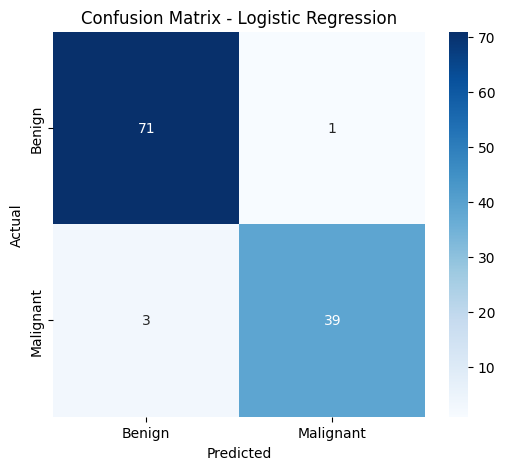

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

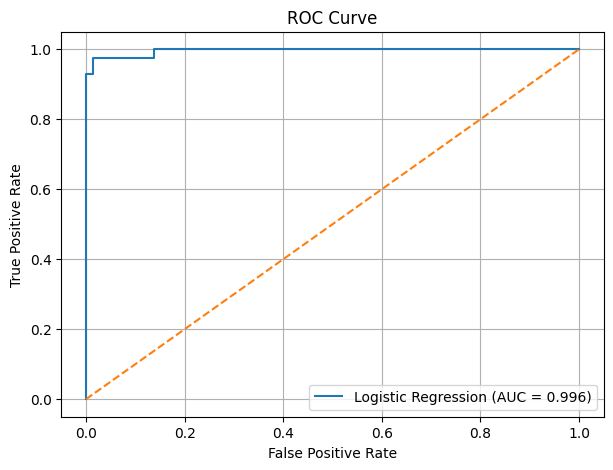

ROC-AUC Score: 0.9960


In [21]:
# Probability of positive class
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

In [22]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
21,worst texture,1.434093,1.434093
10,radius error,1.233325,1.233325
28,worst symmetry,1.061264,1.061264
7,mean concave points,0.952813,0.952813
26,worst concavity,0.911406,0.911406
13,area error,0.909029,0.909029
15,compactness error,-0.906925,0.906925
23,worst area,0.900477,0.900477
20,worst radius,0.896968,0.896968
6,mean concavity,0.782298,0.782298


In [23]:
print("MODEL INTERPRETATION")
print("=" * 50)

print("""
The Logistic Regression model was trained to classify tumors
into two categories: Benign and Malignant.

The model uses tumor-related numerical measurements as input
features.

Positive coefficients increase the model's tendency toward
the positive class (Malignant), while negative coefficients
decrease that tendency, keeping all other features fixed.

The magnitude of a coefficient indicates how strongly the
corresponding feature contributes to the model's decision.
""")

MODEL INTERPRETATION

The Logistic Regression model was trained to classify tumors
into two categories: Benign and Malignant.

The model uses tumor-related numerical measurements as input
features.

Positive coefficients increase the model's tendency toward
the positive class (Malignant), while negative coefficients
decrease that tendency, keeping all other features fixed.

The magnitude of a coefficient indicates how strongly the
corresponding feature contributes to the model's decision.



In [24]:
predictions_df = X_test.copy()

predictions_df["Actual"] = y_test.values
predictions_df["Predicted"] = y_pred
predictions_df["Malignant_Probability"] = y_proba[:, 1]

predictions_df.to_csv(
    "predictions.csv",
    index=False
)

print("predictions.csv created successfully!")

predictions_df.head()

predictions.csv created successfully!


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Actual,Predicted,Malignant_Probability
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523,0,0,0.000365
250,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,...,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849,1,1,1.000000
375,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960,0,0,0.042568
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353,1,1,0.576187
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,...,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675,0,1,0.509155


## Final Results

The Logistic Regression model was trained using the Breast Cancer Wisconsin dataset.

### Steps performed
1. Loaded the dataset
2. Explored the dataset
3. Checked missing values
4. Prepared the target variable
5. Split the data into training and testing sets
6. Standardized numerical features
7. Trained Logistic Regression
8. Generated class predictions
9. Generated probability predictions using predict_proba()
10. Evaluated the model using accuracy and classification report
11. Created a confusion matrix
12. Created an ROC curve and calculated ROC-AUC
13. Interpreted model coefficients
14. Saved the preprocessed dataset and predictions

In [25]:
import joblib

joblib.dump(model, "logistic_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [26]:
import os

print(os.listdir())

['.config', 'predictions.csv', 'preprocessed_breast_cancer.csv', 'scaler.pkl', 'logistic_regression_model.pkl', 'sample_data']
